In [399]:
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
import seaborn as sns

def get_results(path):
    with np.load(path, allow_pickle=True) as data:
        test_result = data["test_result"]
        if isinstance(test_result, np.ndarray) and test_result.shape == ():
            test_result = test_result.item()
        elif isinstance(test_result, np.ndarray) and test_result.dtype == object:
            test_result = np.ravel(test_result)[0]

        df = pd.DataFrame([test_result]) if isinstance(test_result, dict) else pd.DataFrame(test_result)
        return df

def get_predictions(path):
    df = pd.read_csv(path, sep=',')
    df.columns = ["idx", "pred", "target"]
    df["idx"] = df["idx"].str.replace("idx:", "").astype(int)
    df["pred"] = df["pred"].str.replace("pred:", "").astype(int)
    df["target"] = df["target"].str.replace("target:", "").astype(int)
    return df

def slugify(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")

def plot_confusion_matrix(df, title, save_path=None):
    cm = pd.crosstab(df["target"], df["pred"], rownames=["Actual"], colnames=["Predicted"])

    plt.figure(figsize=(7, 5))
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=["No Vuln", "Vul"],
        yticklabels=["No Vuln", "Vul"],
        linewidths=0.5,
    )

    ax.set_title(f"Confusion Matrix - {title}", fontweight="bold", fontsize=16)
    ax.set_xlabel("Predicted", fontweight="bold", fontsize=12)
    ax.set_ylabel("Actual", fontweight="bold", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    plt.setp(ax.get_xticklabels(), fontweight="bold")
    plt.setp(ax.get_yticklabels(), fontweight="bold")
    plt.tight_layout()

    if save_path is None:
        save_path = f"../figures/confusion_matrix_{slugify(title)}.pdf"
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [400]:
import os
os.makedirs("figures", exist_ok=True)


## CodeBERT

In [401]:
import numpy as np
import matplotlib.pyplot as plt

path = "./output/CodeBERT/bacc/result.npz"
df_CodeBERT_base_results = get_results(path)

path = './output/CodeBERT/bacc/predictions.txt'
df_CodeBERT_base_pred = get_predictions(path)

In [402]:
df_CodeBERT_base_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,75.55,8.12,69.31,14.53,75.74,24.26,30.69,72.53


In [403]:
path2 = "./output/CodeBERT/bacc/result.npz"
df_CodeBERT_base_results2 = get_results(path2)
df_CodeBERT_base_results2

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,72.52,7.58,72.91,13.73,72.51,27.49,27.09,72.71


In [404]:
path2 = "./output/UniXCoder/bacc/result.npz"
df_UnixCoder_base_results2 = get_results(path2)
df_UnixCoder_base_results2

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,73.42,7.72,71.76,13.93,73.47,26.53,28.24,72.61


## UniXCoder

In [405]:
path = "./output/UniXCoder/bacc/result.npz"
df_UnixCoder_base_results = get_results(path)

path = './output/UniXCoder/bacc/predictions.txt'
df_UnixCoder_base_pred = get_predictions(path)

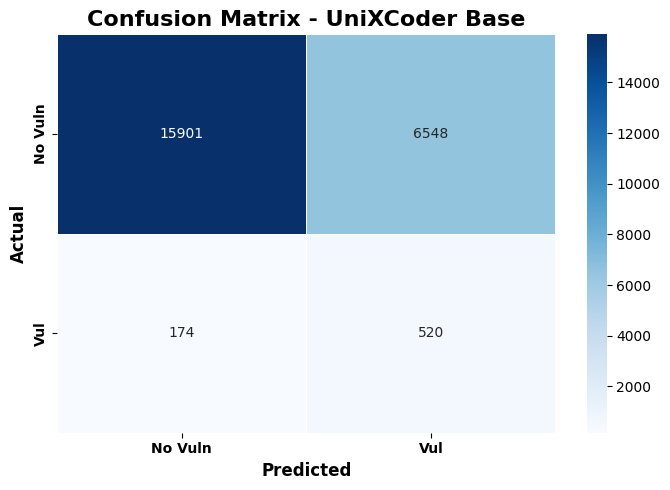

In [406]:
plot_confusion_matrix(df_UnixCoder_base_pred, "UniXCoder Base")

In [407]:
path = './output/UniXCoder_norm/bacc/result.npz'
df_UnixCoder_norm_results2 = get_results(path)
df_UnixCoder_norm_results2


,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,73.42,7.72,71.76,13.93,73.47,26.53,28.24,72.61


### Robustness Checks

1. No normalization

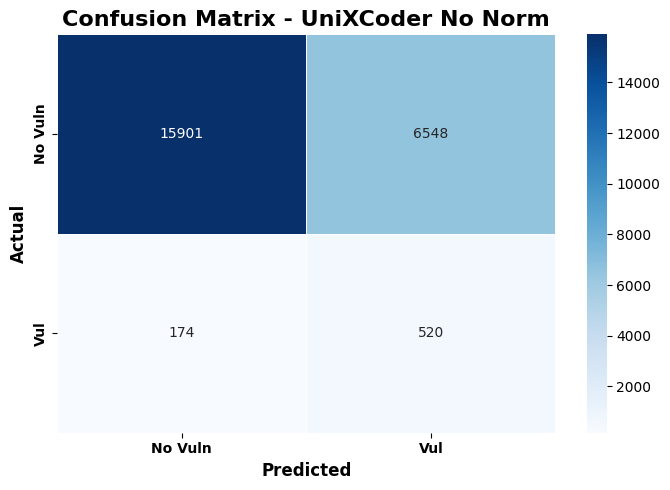

In [408]:
path = './output/UniXCoder_no_norm/bacc/result.npz'
df_UnixCoder_no_norm_results = get_results(path)

path = './output/UniXCoder_no_norm/bacc/predictions.txt'
df_UnixCoder_no_norm_pred = get_predictions(path)
plot_confusion_matrix(df_UnixCoder_no_norm_pred, "UniXCoder No Norm")

In [409]:
path = './output/UniXCoder_no_norm/bacc/result.npz'
df_UnixCoder_no_norm_results2 = get_results(path)

path = './output/UniXCoder_no_norm/bacc/predictions.txt'
df_UnixCoder_no_norm_pred2 = get_predictions(path)
df_UnixCoder_no_norm_results2

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,73.42,7.72,71.76,13.93,73.47,26.53,28.24,72.61


In [410]:
df_UnixCoder_no_norm_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,70.96,7.36,74.93,13.4,70.83,29.17,25.07,72.88


2. Abstract (change of names in variables)

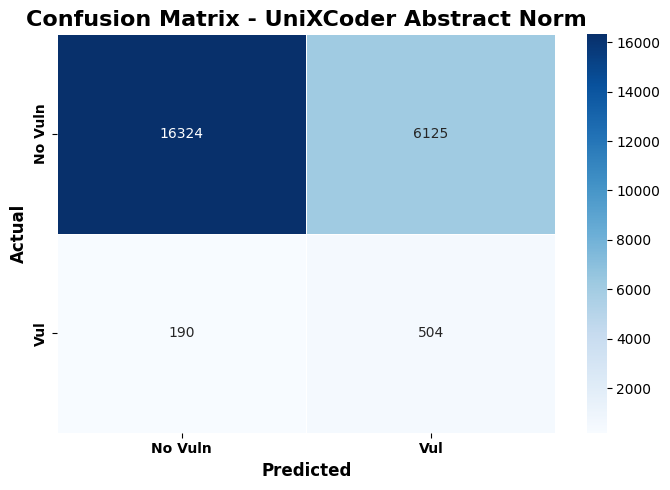

In [411]:
path = './output/UniXCoder_abstract/bacc/result.npz'
df_UnixCoder_abstract_results = get_results(path)

path = './output/UniXCoder_abstract/bacc/predictions.txt'
df_UnixCoder_abstract_pred = get_predictions(path)
plot_confusion_matrix(df_UnixCoder_abstract_pred, "UniXCoder Abstract Norm")

In [412]:
path = './output/UniXCoder_abstract/bacc/result.npz'
df_UnixCoder_abstract_results2 = get_results(path)

path = './output/UniXCoder_abstract/bacc/predictions.txt'
df_UnixCoder_abstract_pred2 = get_predictions(path)
df_UnixCoder_abstract_results2

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,78.08,8.22,62.1,14.52,78.57,21.43,37.9,70.34


In [413]:
df_UnixCoder_abstract_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,72.71,7.6,72.62,13.76,72.72,27.28,27.38,72.67


3. Unseen data

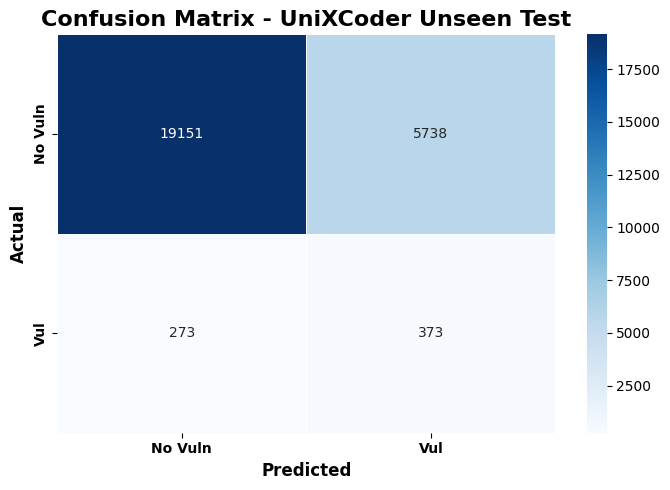

In [414]:
path = './output/UniXCoder_unseen_test/bacc/result.npz'
df_UnixCoder_unseen_test_results = get_results(path)

path = './output/UniXCoder_unseen_test/bacc/predictions.txt'
df_UnixCoder_unseen_test_pred = get_predictions(path)
plot_confusion_matrix(df_UnixCoder_unseen_test_pred, "UniXCoder Unseen Test")

In [415]:
path = './output/UniXCoder_unseen_test/bacc/result.npz'
df_UnixCoder_unseen_test_results2 = get_results(path)

path = './output/UniXCoder_unseen_test/bacc/predictions.txt'
df_UnixCoder_unseen_test_pred2 = get_predictions(path)
df_UnixCoder_unseen_test_results2

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,78.65,6.51,55.73,11.67,79.24,20.76,44.27,67.49


In [416]:
df_UnixCoder_unseen_test_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,76.46,6.1,57.74,11.04,76.95,23.05,42.26,67.34


## DeepSeek-6.7B

In [417]:
path = "./output/DeepSeek-6.7B/bacc/result.npz"
df_DeepSeek_base_results = get_results(path)

path = './output/DeepSeek-6.7B/bacc/predictions.txt'
df_DeepSeek_base_pred = get_predictions(path)

In [418]:
df_DeepSeek_base_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,69.64,7.22,76.95,13.19,69.41,30.59,23.05,73.18


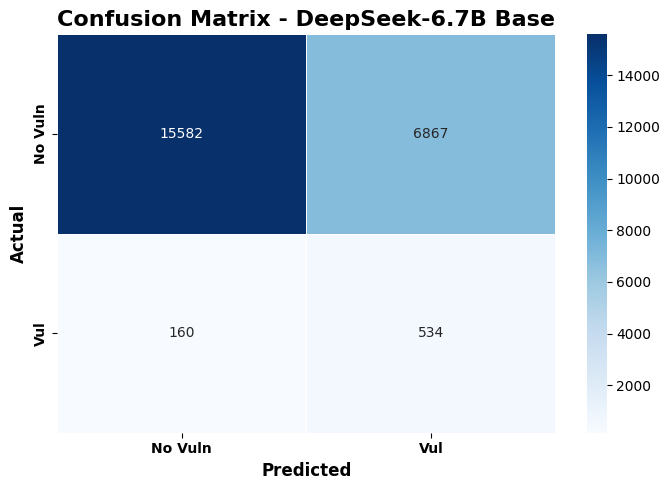

In [419]:
plot_confusion_matrix(df_DeepSeek_base_pred, "DeepSeek-6.7B Base")

## Comparison of models

In [420]:
# Comparison table across all evaluated models (in-distribution test set).
# Mirrors the model list used in the chart cell below -- add rows here as
# more models finish fine-tuning.
import pandas as pd

candidate_models = [
    ("CodeBERT", "df_CodeBERT_base_results2"),
    ("UniXCoder", "df_UnixCoder_base_results2"),
    ("DeepSeek-6.7B", "df_DeepSeek_base_results"),
    ("Qwen2.5-Coder-7B", "df_Qwen_base_results"),
    ("Phi-3.5-mini", "df_Phi_base_results"),
    ("CodeLlama-7B", "df_CodeLlama_base_results"),
]

cols = {}
for name, varname in candidate_models:
    if varname in globals():
        df = globals()[varname]
        cols[name] = df.iloc[0]

comparison_df = pd.DataFrame(cols)
comparison_df.round(2)


,CodeBERT,UniXCoder,DeepSeek-6.7B,Qwen2.5-Coder-7B,Phi-3.5-mini,CodeLlama-7B
test_acc,72.52,73.42,69.64,69.64,68.70,74.24
test_prec,7.58,7.72,7.22,6.91,7.01,7.73
test_recall,72.91,71.76,76.95,73.20,76.95,69.45
test_f1,13.73,13.93,13.19,12.63,12.85,13.92
test_tnr,72.51,73.47,69.41,69.53,68.45,74.39
test_fpr,27.49,26.53,30.59,30.47,31.55,25.61
test_fnr,27.09,28.24,23.05,26.80,23.05,30.55
test_bacc,72.71,72.61,73.18,71.37,72.70,71.92


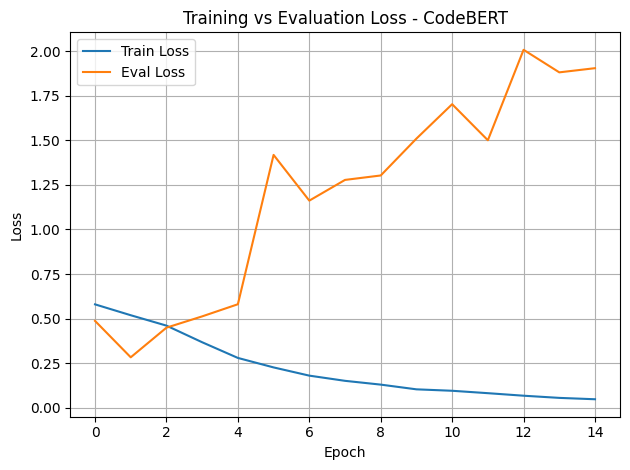

In [421]:
train_loss = [
    0.58029, 0.51931, 0.46107, 0.36788, 0.27996,
    0.22681, 0.18074, 0.15163, 0.1304, 0.10396,
    0.09591, 0.0824, 0.06821, 0.05604, 0.04838
]

eval_loss = [
    0.4876, 0.2835, 0.4496, 0.5129, 0.5809,
    1.418, 1.1617, 1.2778, 1.3027, 1.5094,
    1.7022, 1.5001, 2.0071, 1.8807, 1.9041
]
import matplotlib.pyplot as plt

epochs = list(range(len(train_loss)))

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, eval_loss, label="Eval Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss - CodeBERT")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("../figures/finetune_loss_curves.pdf", bbox_inches="tight")
plt.show()

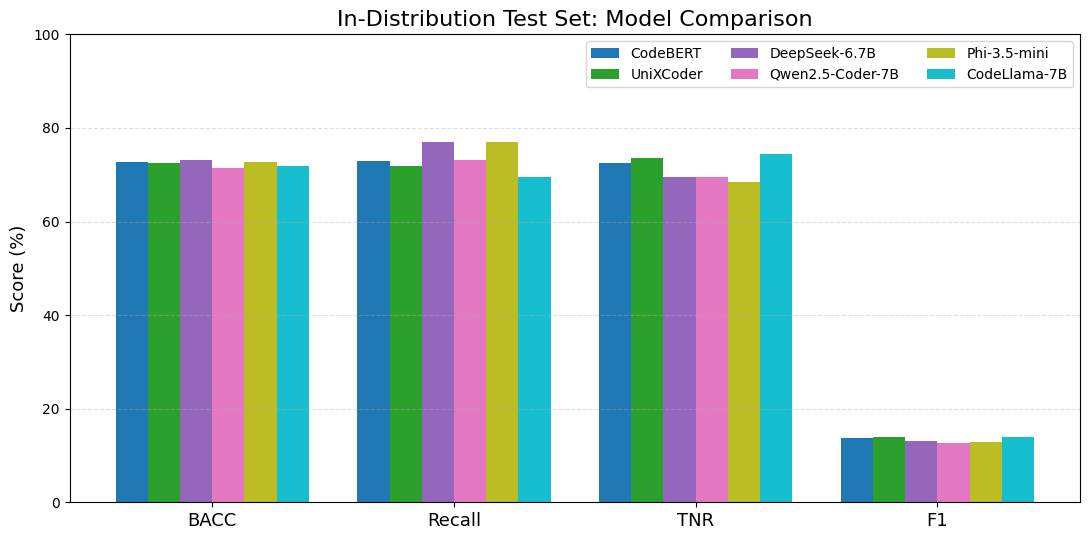

In [422]:
# Grouped bar chart comparing ALL evaluated models on the in-distribution test set.
# Add a (name, results_df) pair here for every model you have results for.
# Models not yet run are skipped automatically, so this cell is safe to run at any
# point during the project -- rerun it as more models finish fine-tuning.

candidate_models = [
    ("CodeBERT", "df_CodeBERT_base_results2"),
    ("UniXCoder", "df_UnixCoder_base_results2"),
    ("DeepSeek-6.7B", "df_DeepSeek_base_results"),
    ("Qwen2.5-Coder-7B", "df_Qwen_base_results"),
    ("Phi-3.5-mini", "df_Phi_base_results"),
    ("CodeLlama-7B", "df_CodeLlama_base_results"),
]

metrics_order = ["test_bacc", "test_recall", "test_tnr", "test_f1"]
metrics_labels = ["BACC", "Recall", "TNR", "F1"]

model_names = []
model_values = []
for name, varname in candidate_models:
    if varname in globals():
        df = globals()[varname]
        model_names.append(name)
        model_values.append(df[metrics_order].iloc[0].to_numpy(dtype=float))

n_models = len(model_names)
x = np.arange(len(metrics_order))
width = 0.8 / max(n_models, 1)

plt.figure(figsize=(11, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, max(n_models, 1)))
for i, (name, vals) in enumerate(zip(model_names, model_values)):
    offset = (i - (n_models - 1) / 2) * width
    plt.bar(x + offset, vals, width, label=name, color=colors[i])

plt.ylabel("Score (%)", fontsize=13)
plt.title("In-Distribution Test Set: Model Comparison", fontsize=16)
plt.xticks(x, metrics_labels, fontsize=13)
plt.ylim(0, 100)
plt.legend(fontsize=10, ncol=min(n_models, 3))
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/finetune_baseline_comparison.pdf", bbox_inches="tight")
plt.show()


In [423]:
df_CodeBERT_base_results2

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,72.52,7.58,72.91,13.73,72.51,27.49,27.09,72.71


In [424]:
df_CodeBERT_base_results2[["test_bacc", "test_recall", "test_prec", "test_tnr", "test_f1"]].round(2)

,test_bacc,test_recall,test_prec,test_tnr,test_f1
0,72.71,72.91,7.58,72.51,13.73


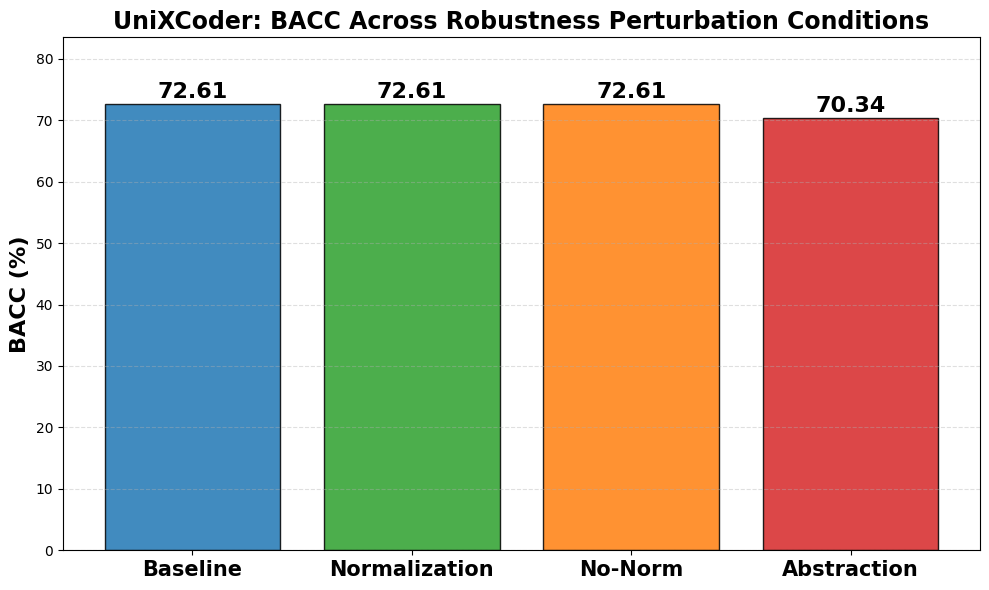

In [425]:
# UniXCoder BACC across all four conditions reported in the thesis
# (Table: baseline, normalization, no-normalization, identifier abstraction).
conditions = ["Baseline", "Normalization", "No-Norm", "Abstraction"]
bacc_values = [
    df_UnixCoder_base_results2["test_bacc"].iloc[0],
    df_UnixCoder_norm_results2["test_bacc"].iloc[0],
    df_UnixCoder_no_norm_results2["test_bacc"].iloc[0],
    df_UnixCoder_abstract_results2["test_bacc"].iloc[0],
]

plt.figure(figsize=(10, 6))
bars = plt.bar(conditions, bacc_values,
                color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"],
                alpha=0.85, edgecolor="black")
plt.xticks(fontsize=15, fontweight="bold")
for bar, value in zip(bars, bacc_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
              f"{value:.2f}", ha="center", va="bottom", fontsize=16, fontweight="bold")

plt.ylabel("BACC (%)", fontsize=16, fontweight="bold")
plt.title("UniXCoder: BACC Across Robustness Perturbation Conditions", fontsize=17, fontweight="bold")
plt.ylim(0, max(bacc_values) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/finetune_robustness_bars.pdf", bbox_inches="tight")
plt.show()


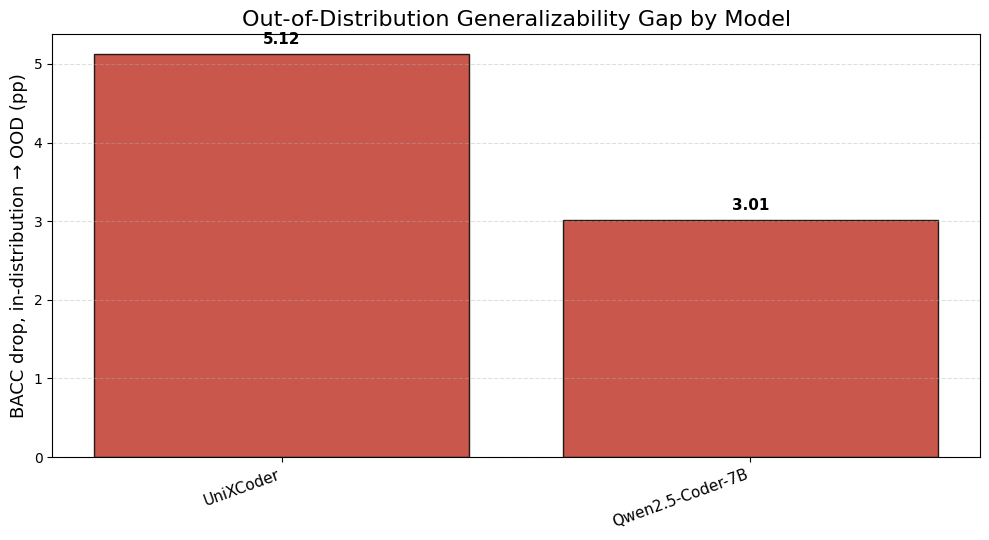

In [426]:
# In-distribution vs OOD comparison, dynamic across all models you have
# OOD (unseen_test) results for. Add a (name, in_dist_var, ood_var) triple
# here for each model; entries are skipped automatically if not yet run,
# so this is safe to run before all OOD jobs finish.

candidate_ood_models = [
    ("CodeBERT",         "df_CodeBERT_base_results2",  "df_CodeBERT_unseen_test_results"),
    ("UniXCoder",        "df_UnixCoder_base_results2", "df_UnixCoder_unseen_test_results2"),
    ("DeepSeek-6.7B",    "df_DeepSeek_base_results",   "df_DeepSeek_unseen_test_results"),
    ("Qwen2.5-Coder-7B", "df_Qwen_base_results",       "df_Qwen_unseen_test_results"),
    ("Phi-3.5-mini",     "df_Phi_base_results",        "df_Phi_unseen_test_results"),
    ("CodeLlama-7B",     "df_CodeLlama_base_results",  "df_CodeLlama_unseen_test_results"),
]

metrics = ["test_bacc", "test_recall", "test_tnr", "test_f1"]
metrics_labels = ["BACC", "Recall", "TNR", "F1"]

available = [
    (name, globals()[id_var], globals()[ood_var])
    for name, id_var, ood_var in candidate_ood_models
    if id_var in globals() and ood_var in globals()
]

if len(available) == 1:
    # Single-model case (e.g. only UniXCoder so far): original grouped
    # in-dist vs OOD bar chart, matches the thesis Chapter 4 figure exactly.
    name, id_df, ood_df = available[0]
    in_dist = id_df[metrics].iloc[0].to_numpy(dtype=float)
    ood = ood_df[metrics].iloc[0].to_numpy(dtype=float)

    x = np.arange(len(metrics))
    width = 0.35
    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, in_dist, width, label="In-distribution test")
    plt.bar(x + width / 2, ood, width, label="OOD NVD (Oct 2023\u2013Oct 2024)")
    plt.ylabel("Score (%)", fontsize=12)
    plt.title(f"{name} Performance: In-distribution vs OOD NVD", fontsize=16)
    plt.xticks(x, metrics_labels, fontsize=14)
    plt.ylim(0, 100)
    plt.legend(fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

else:
    # Multi-model case: BACC drop (ID minus OOD) per model, the single
    # number the thesis discussion focuses on.
    names = [a[0] for a in available]
    bacc_drop = [
        a[1]["test_bacc"].iloc[0] - a[2]["test_bacc"].iloc[0] for a in available
    ]
    plt.figure(figsize=(10, 5.5))
    bars = plt.bar(names, bacc_drop, color="#c0392b", alpha=0.85, edgecolor="black")
    for bar, value in zip(bars, bacc_drop):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                  f"{value:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    plt.ylabel("BACC drop, in-distribution \u2192 OOD (pp)", fontsize=13)
    plt.title("Out-of-Distribution Generalizability Gap by Model", fontsize=16)
    plt.xticks(rotation=20, ha="right", fontsize=11)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../figures/finetune_ood_comparison.pdf", bbox_inches="tight")
plt.show()


## DeepSeek-6.7B — Visualizations

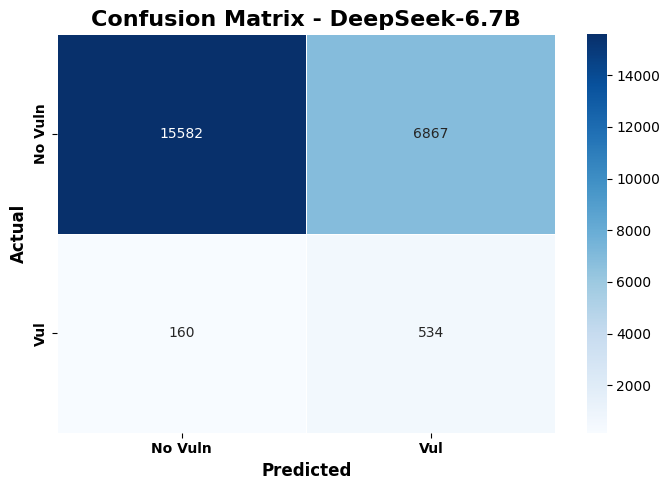

In [427]:
plot_confusion_matrix(df_DeepSeek_base_pred, "DeepSeek-6.7B")

In [452]:
df_DeepSeek_base_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,69.64,7.22,76.95,13.19,69.41,30.59,23.05,73.18


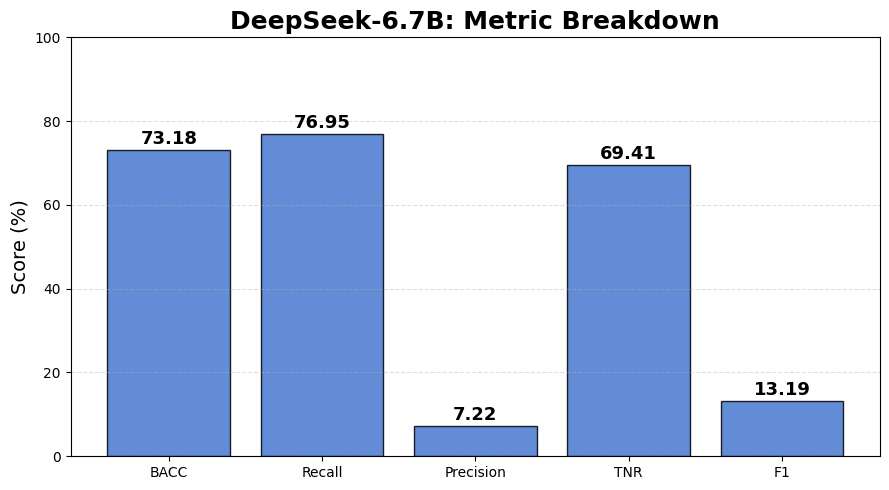

In [428]:
# DeepSeek-6.7B metric breakdown
metrics_labels = ["BACC", "Recall", "Precision", "TNR", "F1"]
metrics_values = df_DeepSeek_base_results[
    ["test_bacc", "test_recall", "test_prec", "test_tnr", "test_f1"]
].iloc[0].to_numpy()

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics_labels, metrics_values, color="#4878d0", alpha=0.85, edgecolor="black")
for bar, value in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{value:.2f}", ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.ylabel("Score (%)", fontsize=14)
plt.title("DeepSeek-6.7B: Metric Breakdown", fontsize=18, fontweight="bold")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/metric_breakdown_deepseek.pdf", bbox_inches="tight")
plt.show()


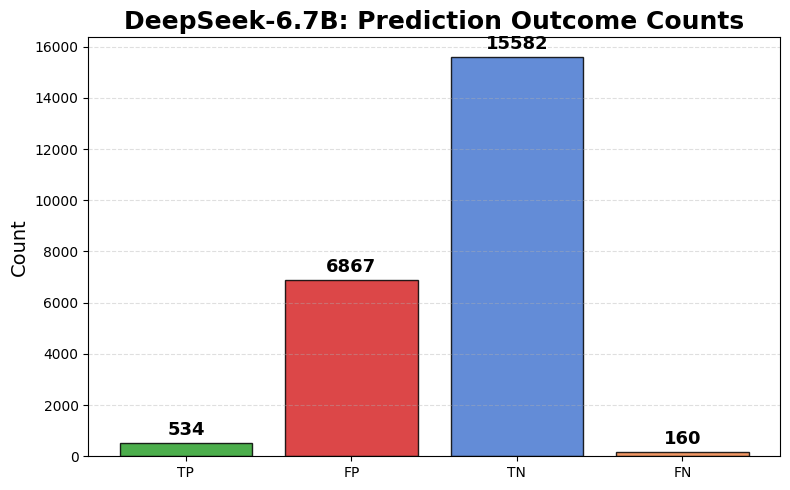

In [429]:
# DeepSeek-6.7B prediction outcome counts (TP / FP / TN / FN)
outcome_counts = {
    "TP": ((df_DeepSeek_base_pred["pred"] == 1) & (df_DeepSeek_base_pred["target"] == 1)).sum(),
    "FP": ((df_DeepSeek_base_pred["pred"] == 1) & (df_DeepSeek_base_pred["target"] == 0)).sum(),
    "TN": ((df_DeepSeek_base_pred["pred"] == 0) & (df_DeepSeek_base_pred["target"] == 0)).sum(),
    "FN": ((df_DeepSeek_base_pred["pred"] == 0) & (df_DeepSeek_base_pred["target"] == 1)).sum(),
}

plt.figure(figsize=(8, 5))
bars = plt.bar(outcome_counts.keys(), outcome_counts.values(),
                color=["#2ca02c", "#d62728", "#4878d0", "#ee854a"], alpha=0.85, edgecolor="black")
for bar, value in zip(bars, outcome_counts.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(outcome_counts.values()) * 0.01,
              f"{value}", ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.ylabel("Count", fontsize=14)
plt.title("DeepSeek-6.7B: Prediction Outcome Counts", fontsize=18, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/outcome_counts_deepseek.pdf", bbox_inches="tight")
plt.show()


## Qwen2.5-Coder-7B

In [430]:
path = "./output/Qwen2.5-Coder-7B/bacc/result.npz"
df_Qwen_base_results = get_results(path)

path = './output/Qwen2.5-Coder-7B/bacc/predictions.txt'
df_Qwen_base_pred = get_predictions(path)

In [431]:
df_Qwen_base_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,69.64,6.91,73.2,12.63,69.53,30.47,26.8,71.37


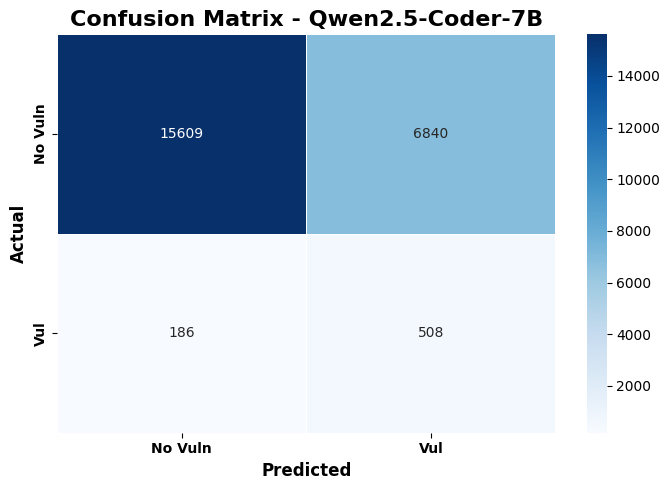

In [432]:
plot_confusion_matrix(df_Qwen_base_pred, "Qwen2.5-Coder-7B")

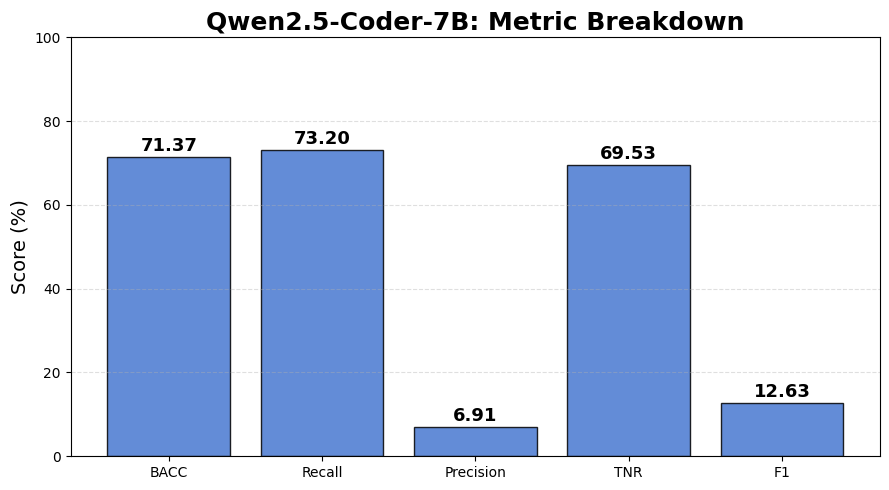

In [433]:
# Qwen2.5-Coder-7B metric breakdown
metrics_labels = ["BACC", "Recall", "Precision", "TNR", "F1"]
metrics_values = df_Qwen_base_results[
    ["test_bacc", "test_recall", "test_prec", "test_tnr", "test_f1"]
].iloc[0].to_numpy()

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics_labels, metrics_values, color="#4878d0", alpha=0.85, edgecolor="black")
for bar, value in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{value:.2f}", ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.ylabel("Score (%)", fontsize=14)
plt.title("Qwen2.5-Coder-7B: Metric Breakdown", fontsize=18, fontweight="bold")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/metric_breakdown_qwen.pdf", bbox_inches="tight")
plt.show()


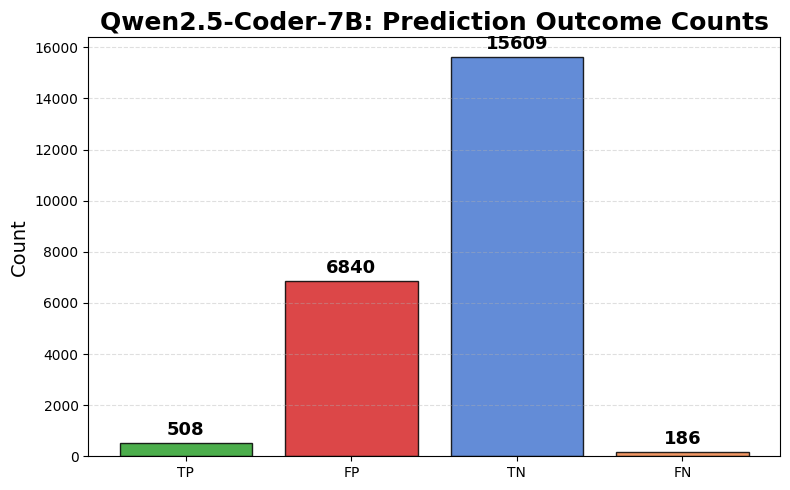

In [434]:
# Qwen2.5-Coder-7B prediction outcome counts (TP / FP / TN / FN)
outcome_counts = {
    "TP": ((df_Qwen_base_pred["pred"] == 1) & (df_Qwen_base_pred["target"] == 1)).sum(),
    "FP": ((df_Qwen_base_pred["pred"] == 1) & (df_Qwen_base_pred["target"] == 0)).sum(),
    "TN": ((df_Qwen_base_pred["pred"] == 0) & (df_Qwen_base_pred["target"] == 0)).sum(),
    "FN": ((df_Qwen_base_pred["pred"] == 0) & (df_Qwen_base_pred["target"] == 1)).sum(),
}

plt.figure(figsize=(8, 5))
bars = plt.bar(outcome_counts.keys(), outcome_counts.values(),
                color=["#2ca02c", "#d62728", "#4878d0", "#ee854a"], alpha=0.85, edgecolor="black")
for bar, value in zip(bars, outcome_counts.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(outcome_counts.values()) * 0.01,
              f"{value}", ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.ylabel("Count", fontsize=14)
plt.title("Qwen2.5-Coder-7B: Prediction Outcome Counts", fontsize=18, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/outcome_counts_qwen.pdf", bbox_inches="tight")
plt.show()


## Phi-3.5-mini

In [435]:
path = "./output/Phi-3.5-mini/bacc/result.npz"
df_Phi_base_results = get_results(path)

path = './output/Phi-3.5-mini/bacc/predictions.txt'
df_Phi_base_pred = get_predictions(path)


In [436]:
df_Phi_base_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,68.7,7.01,76.95,12.85,68.45,31.55,23.05,72.7


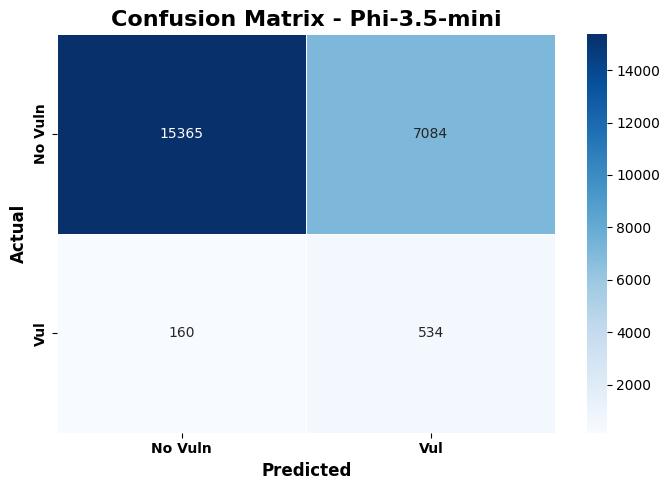

In [437]:
plot_confusion_matrix(df_Phi_base_pred, "Phi-3.5-mini")

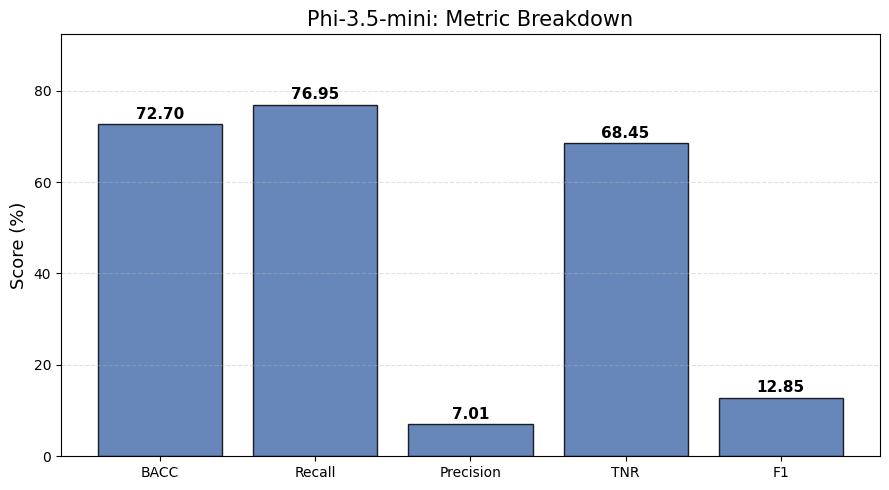

In [438]:
# Phi-3.5-mini metric breakdown
metrics_labels = ["BACC", "Recall", "Precision", "TNR", "F1"]
metrics_values = df_Phi_base_results[
    ["test_bacc", "test_recall", "test_prec", "test_tnr", "test_f1"]
].iloc[0].to_numpy()

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics_labels, metrics_values, color="#4c72b0", edgecolor="black", alpha=0.85)
for bar, value in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{value:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.ylabel("Score (%)", fontsize=13)
plt.title("Phi-3.5-mini: Metric Breakdown", fontsize=15)
plt.ylim(0, max(metrics_values) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/metric_breakdown_phi.pdf", bbox_inches="tight")
plt.show()


In [439]:
# Phi-3.5-mini prediction outcome counts (TP / FP / TN / FN)
outcome_counts = {
    "TP": ((df_Phi_base_pred["pred"] == 1) & (df_Phi_base_pred["target"] == 1)).sum(),
    "FP": ((df_Phi_base_pred["pred"] == 1) & (df_Phi_base_pred["target"] == 0)).sum(),
    "TN": ((df_Phi_base_pred["pred"] == 0) & (df_Phi_base_pred["target"] == 0)).sum(),
    "FN": ((df_Phi_base_pred["pred"] == 0) & (df_Phi_base_pred["target"] == 1)).sum(),
}
outcome_counts


{'TP': np.int64(534),
 'FP': np.int64(7084),
 'TN': np.int64(15365),
 'FN': np.int64(160)}

## CodeLlama-7B

In [440]:
path = "./output/CodeLlama-7B/bacc/result.npz"
df_CodeLlama_base_results = get_results(path)

path = './output/CodeLlama-7B/bacc/predictions.txt'
df_CodeLlama_base_pred = get_predictions(path)


In [441]:
df_CodeLlama_base_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,74.24,7.73,69.45,13.92,74.39,25.61,30.55,71.92


In [442]:
model_result_vars = {
    "CodeBERT": df_CodeBERT_base_results2,
    "UniXCoder": df_UnixCoder_base_results2,
    "DeepSeek-6.7B": df_DeepSeek_base_results,
    "Qwen2.5-Coder-7B": df_Qwen_base_results,
    "Phi-3.5-mini": df_Phi_base_results,
    "CodeLlama-7B": df_CodeLlama_base_results,
}

all_models_df = (
    pd.concat(
        {name: df.iloc[0] for name, df in model_result_vars.items()},
        axis=1
    )
    .T
    .reset_index()
    .rename(columns={"index": "model"})
)

all_models_df.round(2)

,model,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,CodeBERT,72.52,7.58,72.91,13.73,72.51,27.49,27.09,72.71
1,UniXCoder,73.42,7.72,71.76,13.93,73.47,26.53,28.24,72.61
2,DeepSeek-6.7B,69.64,7.22,76.95,13.19,69.41,30.59,23.05,73.18
3,Qwen2.5-Coder-7B,69.64,6.91,73.20,12.63,69.53,30.47,26.80,71.37
4,Phi-3.5-mini,68.70,7.01,76.95,12.85,68.45,31.55,23.05,72.70
5,CodeLlama-7B,74.24,7.73,69.45,13.92,74.39,25.61,30.55,71.92


In [443]:
df_Phi_base_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,68.7,7.01,76.95,12.85,68.45,31.55,23.05,72.7


In [444]:
df_CodeLlama_base_results

,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,74.24,7.73,69.45,13.92,74.39,25.61,30.55,71.92


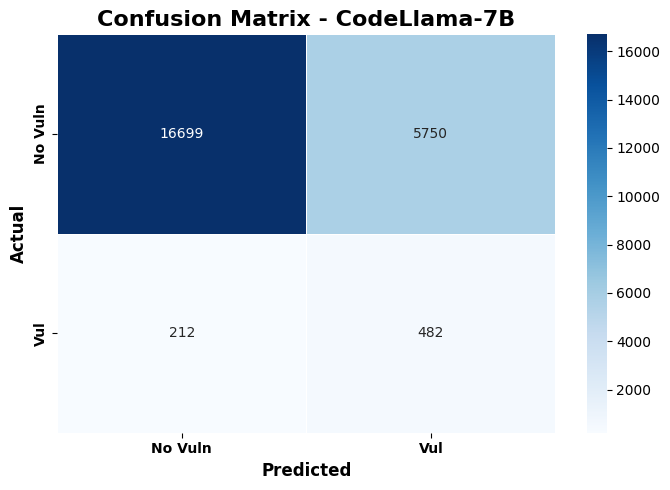

In [445]:
plot_confusion_matrix(df_CodeLlama_base_pred, "CodeLlama-7B")

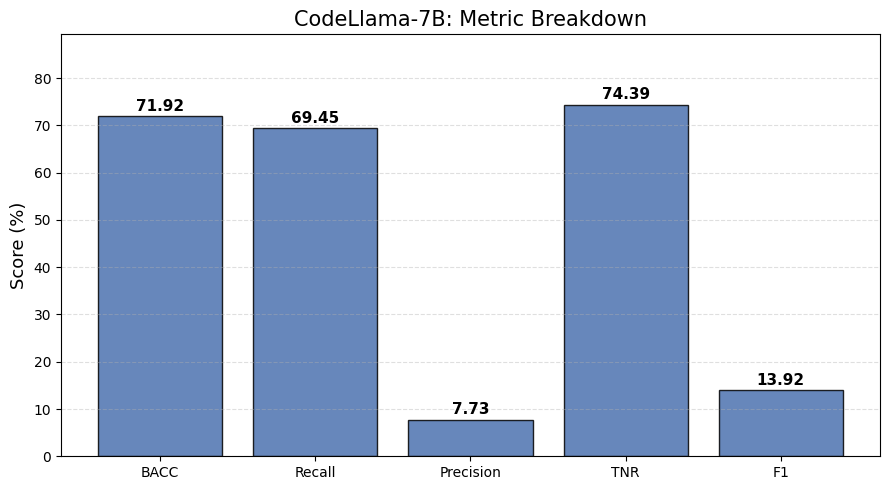

In [446]:
# CodeLlama-7B metric breakdown
metrics_labels = ["BACC", "Recall", "Precision", "TNR", "F1"]
metrics_values = df_CodeLlama_base_results[
    ["test_bacc", "test_recall", "test_prec", "test_tnr", "test_f1"]
].iloc[0].to_numpy()

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics_labels, metrics_values, color="#4c72b0", edgecolor="black", alpha=0.85)
for bar, value in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{value:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.ylabel("Score (%)", fontsize=13)
plt.title("CodeLlama-7B: Metric Breakdown", fontsize=15)
plt.ylim(0, max(metrics_values) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/metric_breakdown_codellama.pdf", bbox_inches="tight")
plt.show()


In [447]:
# CodeLlama-7B prediction outcome counts (TP / FP / TN / FN)
outcome_counts = {
    "TP": ((df_CodeLlama_base_pred["pred"] == 1) & (df_CodeLlama_base_pred["target"] == 1)).sum(),
    "FP": ((df_CodeLlama_base_pred["pred"] == 1) & (df_CodeLlama_base_pred["target"] == 0)).sum(),
    "TN": ((df_CodeLlama_base_pred["pred"] == 0) & (df_CodeLlama_base_pred["target"] == 0)).sum(),
    "FN": ((df_CodeLlama_base_pred["pred"] == 0) & (df_CodeLlama_base_pred["target"] == 1)).sum(),
}
outcome_counts


{'TP': np.int64(482),
 'FP': np.int64(5750),
 'TN': np.int64(16699),
 'FN': np.int64(212)}

**Note:** after running the two sections above, scroll back up and re-run the *"In-Distribution Test Set: Model Comparison"* cell (under `## Comparison of models`) so that Phi-3.5-mini and CodeLlama-7B are included in `../figures/finetune_baseline_comparison.pdf`.

## Out-of-Distribution Results (Large LMs)\n\nLoads the `_unseen_test` results produced by `run_llm_robustness_ood.sh`. Run this after that script finishes; re-run the dynamic OOD comparison cell above afterwards to fold these into `finetune_ood_comparison.pdf`.

In [448]:
# # DeepSeek-6.7B -- OOD (unseen_test) results
# path = "./output/DeepSeek-6.7B_unseen_test/bacc/result.npz"
# df_DeepSeek_unseen_test_results = get_results(path)

# path = "./output/DeepSeek-6.7B_unseen_test/bacc/predictions.txt"
# df_DeepSeek_unseen_test_pred = get_predictions(path)
# df_DeepSeek_unseen_test_results


In [449]:
# Qwen2.5-Coder-7B -- OOD (unseen_test) results
path = "./output/Qwen2.5-Coder-7B_unseen_test/bacc/result.npz"
df_Qwen_unseen_test_results = get_results(path)

path = "./output/Qwen2.5-Coder-7B_unseen_test/bacc/predictions.txt"
df_Qwen_unseen_test_pred = get_predictions(path)
df_Qwen_unseen_test_results


,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,75.65,6.17,60.68,11.2,76.04,23.96,39.32,68.36


In [450]:
# Phi-3.5-mini -- OOD (unseen_test) results
path = "./output/Phi-3.5-mini_unseen_test/bacc/result.npz"
df_Phi_unseen_test_results = get_results(path)

path = "./output/Phi-3.5-mini_unseen_test/bacc/predictions.txt"
df_Phi_unseen_test_pred = get_predictions(path)
df_Phi_unseen_test_results


,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,75.54,6.33,62.85,11.5,75.87,24.13,37.15,69.36


In [451]:
# CodeLlama-7B -- OOD (unseen_test) results
path = "./output/CodeLlama-7B_unseen_test/bacc/result.npz"
df_CodeLlama_unseen_test_results = get_results(path)

path = "./output/CodeLlama-7B_unseen_test/bacc/predictions.txt"
df_CodeLlama_unseen_test_pred = get_predictions(path)
df_CodeLlama_unseen_test_results


,test_acc,test_prec,test_recall,test_f1,test_tnr,test_fpr,test_fnr,test_bacc
0,79.56,6.88,56.5,12.27,80.16,19.84,43.5,68.33
